# Week4
## Strict Fixed-Baseline-Template Sorting on Compressed-Reconstructed Data

This notebook performs strict sorting on compressed data using baseline templates only.
No baseline spike-time candidate anchoring is used for sorting.


In [1]:
import gc
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from kilosort import template_matching as ks_tm
from kilosort.preprocessing import get_drift_matrix

ROOT = Path('F:/academic')
DATA_ROOT = ROOT / '.test_data'
BASE_RESULTS = DATA_ROOT / 'kilosort4'
STRICT_BIN_PREFERRED_RATIOS = (0.10, 0.20)

def resolve_existing_compressed_bin(root=ROOT, preferred_ratios=STRICT_BIN_PREFERRED_RATIOS):
    for ratio in preferred_ratios:
        candidate = root / f'whitened_recon_ratio_{ratio:.2f}.bin'
        if candidate.exists() and candidate.stat().st_size > 0:
            return candidate
    return None

def infer_src_n_chan_from_bin(bin_path, dtype=np.float32, candidates=(383, 385)):
    size = Path(bin_path).stat().st_size
    item = np.dtype(dtype).itemsize
    ok = []
    for ch in candidates:
        if size % (ch * item) == 0:
            ok.append(ch)
    if not ok:
        raise ValueError(f'Cannot infer channel count for {bin_path} from size={size}.')
    return 383 if 383 in ok else ok[0]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cuda


In [2]:
# Load baseline templates/results from uncompressed data
templates_base = np.load(BASE_RESULTS / 'templates.npy')  # [n_templates, nt, n_chan_tpl]
ops_base = np.load(BASE_RESULTS / 'ops.npy', allow_pickle=True).item()
st_base = np.load(BASE_RESULTS / 'spike_times.npy').squeeze().astype(np.int64)
clu_base = np.load(BASE_RESULTS / 'spike_clusters.npy').squeeze().astype(np.int64)

n_templates, nt, n_chan_tpl = templates_base.shape
print('templates_base shape:', templates_base.shape)

# Strict-sort input bin is resolved later at runtime, after reconstructed bins exist.
compressed_bin = None
data_dtype = np.float32
src_n_chan = None
raw = None
n_samples = None
data_cmp = None
n_use = min(n_chan_tpl, 383)
templates_fixed = templates_base[:, :, :n_use].astype(np.float32, copy=False)
print('templates_fixed shape:', templates_fixed.shape)


templates_base shape: (267, 61, 383)
templates_fixed shape: (267, 61, 383)


### Note: 383 vs 385 channels
Baseline runs may use full probe channel definitions (e.g., including extra/sync/reference channels).
Compressed reconstructed data here has 383 channels; fixed-template matching uses shared channels only.


## Multi-Ratio Comparison and Reconstructed-Bin Preparation
This section now appears **before** strict fixed-template sorting because the strict-sort path may need `whitened_recon_ratio_*.bin` to exist first.

If a reconstructed bin is missing, it can be generated from `whitened_data.npy` using DCT keep-ratio compression + IDCT reconstruction. Here `whitened_data.npy` refers to the CAR-corrected, bandpass-filtered, and spatially whitened signal prepared upstream in `2.ipynb` via **Kilosort built-in preprocessing**.

In other words, the notebook order is now:
1. load baseline results
2. define reconstructed-bin helpers
3. prepare / rebuild missing reconstructed bins when needed
4. run strict fixed-template sorting


In [3]:
# RERUN NOTE: Rerun this cell and all dependent cells after 2.ipynb regenerates whitened_data.npy. It controls how missing reconstructed bins are rebuilt from the updated upstream preprocessing.
from scipy.fftpack import dct, idct
from datetime import datetime
import os
import time

def get_baseline_valid_chan_map(stored_baseline_res=None):
    if stored_baseline_res is None:
        br = np.load(ROOT / 'baseline_results.npy', allow_pickle=True).item()
    else:
        br = stored_baseline_res

    if 'probe' in br['ops'] and 'chanMap' in br['ops']['probe']:
        valid_chan_map = np.asarray(br['ops']['probe']['chanMap']).reshape(-1).astype(np.int32)
    else:
        valid_chan_map = np.arange(len(np.asarray(br['xc']).reshape(-1)), dtype=np.int32)
    return valid_chan_map

def align_whitened_to_baseline_channels(whitened_data, valid_chan_map):
    if whitened_data.shape[1] > len(valid_chan_map):
        return whitened_data[:, valid_chan_map]
    return whitened_data

def compress_whitened_to_coeff(whitened_data, keep_ratio, out_prefix='whitened_dct'):
    n_samples, n_chan = whitened_data.shape
    n_keep = max(1, int(n_samples * keep_ratio))
    # Unique filename each run to avoid Windows mmap overwrite lock
    ts = datetime.now().strftime('%Y%m%d_%H%M%S_%f')
    coeff_path = ROOT / f'{out_prefix}_ratio_{keep_ratio:.2f}_coeff_rebuild_{ts}.npy'

    coeff_mm = np.memmap(str(coeff_path), dtype='float32', mode='w+', shape=(n_keep, n_chan))
    for ch in range(n_chan):
        c = dct(whitened_data[:, ch].astype(np.float32, copy=False), norm='ortho')
        coeff_mm[:, ch] = c[:n_keep].astype('float32', copy=False)
    coeff_mm.flush()
    del coeff_mm
    return coeff_path, n_keep

def is_valid_float32_bin(bin_path, candidate_channels=(383, 385)):
    bin_path = Path(bin_path)
    if not bin_path.exists() or bin_path.stat().st_size == 0:
        return False
    item = np.dtype(np.float32).itemsize
    for ch in candidate_channels:
        if bin_path.stat().st_size % (ch * item) == 0:
            return True
    return False

def load_npy_dict_if_valid(path, required_keys=None):
    path = Path(path)
    if not path.exists() or path.stat().st_size == 0:
        return None
    try:
        obj = np.load(path, allow_pickle=True).item()
        if not isinstance(obj, dict):
            return None
        if required_keys is not None and not set(required_keys).issubset(obj.keys()):
            return None
        return obj
    except Exception:
        return None

def ratio_eval_cache_path(keep_ratio):
    return ROOT / f'week4_ratio_{keep_ratio:.2f}_binned_eval.npy'

def _release_bin_readers(bin_path):
    target = Path(bin_path).resolve()
    released = []
    for name in ('raw', 'data_cmp'):
        obj = globals().get(name, None)
        base = getattr(obj, 'base', None)
        mm = obj if isinstance(obj, np.memmap) else (base if isinstance(base, np.memmap) else None)
        if mm is None:
            continue
        try:
            if Path(mm.filename).resolve() == target:
                del globals()[name]
                released.append(name)
        except Exception:
            pass
    gc.collect()
    return released

def decompress_coeff_to_bin(coeff_path, n_samples, n_chan, n_keep, out_bin, retries=10, delay_s=0.2):
    out_bin = Path(out_bin)
    tmp_bin = out_bin.with_suffix(out_bin.suffix + '.tmp')

    coeff_mm = np.memmap(str(coeff_path), dtype='float32', mode='r', shape=(n_keep, n_chan))
    recon_mm = np.memmap(str(tmp_bin), dtype='float32', mode='w+', shape=(n_samples, n_chan))

    for ch in range(n_chan):
        c_full = np.zeros(n_samples, dtype='float32')
        c_full[:n_keep] = coeff_mm[:, ch]
        recon_mm[:, ch] = idct(c_full, norm='ortho').astype('float32', copy=False)

    recon_mm.flush()
    del coeff_mm, recon_mm
    gc.collect()

    _release_bin_readers(out_bin)

    last_err = None
    for _ in range(retries):
        try:
            os.replace(tmp_bin, out_bin)
            return out_bin
        except PermissionError as e:
            last_err = e
            time.sleep(delay_s)

    raise PermissionError(f'Failed to replace {out_bin} after {retries} retries; file is still in use.') from last_err

def ensure_recon_bin_for_ratio(keep_ratio, whitened_data=None, force_rebuild=False):
    recon_bin = ROOT / f'whitened_recon_ratio_{keep_ratio:.2f}.bin'
    if (not force_rebuild) and is_valid_float32_bin(recon_bin):
        print(f'[ratio={keep_ratio:.2f}] using existing: {recon_bin.name}')
        return recon_bin

    if whitened_data is None:
        wp = ROOT / 'whitened_data.npy'
        if not wp.exists():
            raise FileNotFoundError('whitened_data.npy (CAR-corrected, bandpass-filtered, whitened) is required to generate missing recon bins.')
        whitened_data = np.load(wp, mmap_mode='r')

    valid_chan_map = get_baseline_valid_chan_map()
    whitened_aligned = align_whitened_to_baseline_channels(whitened_data, valid_chan_map)

    print(f'[ratio={keep_ratio:.2f}] generating with unified channel standard: {whitened_aligned.shape[1]} channels')
    coeff_path, n_keep = compress_whitened_to_coeff(whitened_aligned, keep_ratio, out_prefix='whitened_dct')
    recon_bin = decompress_coeff_to_bin(
        coeff_path=coeff_path,
        n_samples=whitened_aligned.shape[0],
        n_chan=whitened_aligned.shape[1],
        n_keep=n_keep,
        out_bin=recon_bin
    )
    print(f'[ratio={keep_ratio:.2f}] generated: {recon_bin.name}')
    return recon_bin


In [4]:
def infer_src_n_chan_from_bin(bin_path, dtype=np.float32, candidates=(383, 385)):
    size = Path(bin_path).stat().st_size
    item = np.dtype(dtype).itemsize
    ok = []
    for ch in candidates:
        if size % (ch * item) == 0:
            ok.append(ch)
    if not ok:
        raise ValueError(f'Cannot infer channel count for {bin_path} from size={size}.')
    # Prefer 383 for backward compatibility if both somehow divide.
    return 383 if 383 in ok else ok[0]


STRICT_SORT_PIPELINE_VERSION = 'int16_main_v2'
RATIO_EVAL_PIPELINE_VERSION = 'int16_main_v2'


def get_quant_meta_for_bin(bin_path):
    bin_path = Path(bin_path)
    stem = bin_path.stem
    if stem.endswith('_int16'):
        meta_path = bin_path.with_name(stem + '_meta.npy')
        if meta_path.exists() and meta_path.stat().st_size > 0:
            try:
                meta = np.load(meta_path, allow_pickle=True).item()
                if isinstance(meta, dict):
                    return meta
            except Exception:
                return None
    return None


def quantized_int16_bin_path(float32_bin_path):
    float32_bin_path = Path(float32_bin_path)
    return float32_bin_path.with_name(float32_bin_path.stem + '_int16.bin')


def quantized_int16_meta_path(float32_bin_path):
    int16_bin = quantized_int16_bin_path(float32_bin_path)
    return int16_bin.with_name(int16_bin.stem + '_meta.npy')


def load_int16_quant_meta(meta_path):
    meta_path = Path(meta_path)
    if not meta_path.exists() or meta_path.stat().st_size == 0:
        return None
    try:
        meta = np.load(meta_path, allow_pickle=True).item()
        return meta if isinstance(meta, dict) else None
    except Exception:
        return None


def is_valid_int16_quantized(int16_bin_path, meta_path=None):
    int16_bin_path = Path(int16_bin_path)
    meta_path = Path(meta_path) if meta_path is not None else int16_bin_path.with_name(int16_bin_path.stem + '_meta.npy')
    if not int16_bin_path.exists() or int16_bin_path.stat().st_size == 0:
        return False
    meta = load_int16_quant_meta(meta_path)
    if meta is None:
        return False
    required = {'n_samples', 'n_chan', 'scales', 'source_float32_bin', 'source_size_bytes'}
    if not required.issubset(meta.keys()):
        return False
    try:
        n_samples = int(meta['n_samples'])
        n_chan = int(meta['n_chan'])
        scales = np.asarray(meta['scales'], dtype=np.float32)
    except Exception:
        return False
    if scales.shape != (n_chan,):
        return False
    expected_bytes = n_samples * n_chan * np.dtype(np.int16).itemsize
    return int16_bin_path.stat().st_size == expected_bytes


def quantize_recon_bin_to_int16(float32_bin_path, keep_ratio, overwrite=False):
    float32_bin_path = Path(float32_bin_path)
    int16_bin = quantized_int16_bin_path(float32_bin_path)
    meta_path = quantized_int16_meta_path(float32_bin_path)

    src_n_chan = infer_src_n_chan_from_bin(float32_bin_path, dtype=np.float32)
    raw = np.memmap(float32_bin_path, dtype=np.float32, mode='r')
    n_samples = raw.size // src_n_chan
    data = raw[: n_samples * src_n_chan].reshape(n_samples, src_n_chan)

    src_stat = float32_bin_path.stat()
    if (not overwrite) and is_valid_int16_quantized(int16_bin, meta_path):
        meta = load_int16_quant_meta(meta_path)
        same_source = (
            Path(meta.get('source_float32_bin', '')) == float32_bin_path and
            int(meta.get('source_size_bytes', -1)) == int(src_stat.st_size) and
            int(meta.get('source_mtime_ns', -1)) == int(getattr(src_stat, 'st_mtime_ns', int(src_stat.st_mtime * 1e9)))
        )
        if same_source:
            return int16_bin, meta_path

    peak = np.max(np.abs(data), axis=0).astype(np.float32)
    scales = np.where(peak > 0, peak / np.float32(32767.0), np.float32(1.0)).astype(np.float32)

    q = np.memmap(int16_bin, dtype=np.int16, mode='w+', shape=(n_samples, src_n_chan))
    for ch in range(src_n_chan):
        q[:, ch] = np.clip(np.rint(data[:, ch] / scales[ch]), -32767, 32767).astype(np.int16)
    q.flush()
    del q, raw, data
    gc.collect()

    meta = {
        'pipeline_version': RATIO_EVAL_PIPELINE_VERSION,
        'source_float32_bin': str(float32_bin_path),
        'source_size_bytes': int(src_stat.st_size),
        'source_mtime_ns': int(getattr(src_stat, 'st_mtime_ns', int(src_stat.st_mtime * 1e9))),
        'keep_ratio': float(keep_ratio),
        'n_samples': int(n_samples),
        'n_chan': int(src_n_chan),
        'dtype_storage': 'int16',
        'dtype_compute': 'float32_via_scale_restore',
        'scales': scales,
    }
    np.save(meta_path, meta, allow_pickle=True)
    return int16_bin, meta_path


def load_bin_window_as_float32(bin_path, start, stop, candidates=(383, 385)):
    bin_path = Path(bin_path)
    meta = get_quant_meta_for_bin(bin_path)
    if meta is not None:
        n_samples_local = int(meta['n_samples'])
        n_chan_local = int(meta['n_chan'])
        start = max(0, int(start))
        stop = min(int(stop), n_samples_local)
        raw = np.memmap(bin_path, dtype=np.int16, mode='r', shape=(n_samples_local, n_chan_local))
        block_i16 = np.asarray(raw[start:stop], dtype=np.int16)
        scales = np.asarray(meta['scales'], dtype=np.float32)
        block = block_i16.astype(np.float32) * scales[None, :]
        return block, n_samples_local, n_chan_local, meta

    src_n_chan = infer_src_n_chan_from_bin(bin_path, dtype=np.float32, candidates=candidates)
    raw = np.memmap(bin_path, dtype=np.float32, mode='r')
    n_samples_local = raw.size // src_n_chan
    start = max(0, int(start))
    stop = min(int(stop), n_samples_local)
    data_local = raw[: n_samples_local * src_n_chan].reshape(n_samples_local, src_n_chan)
    block = np.asarray(data_local[start:stop], dtype=np.float32)
    return block, n_samples_local, src_n_chan, None


def maybe_apply_drift_correction(X_np, ops, dshift, sample_start, sample_stop, device):
    if dshift is None:
        return X_np
    if not ('iKxx' in ops and 'yblk' in ops and 'probe' in ops and 'batch_size' in ops):
        return X_np

    batch_size = int(ops.get('batch_size', X_np.shape[1]))
    center_sample = max(0, (int(sample_start) + int(sample_stop)) // 2)
    ibatch = min(max(center_sample // batch_size, 0), len(dshift) - 1)

    ops_for_drift = dict(ops)
    ops_for_drift['iKxx'] = torch.as_tensor(ops['iKxx'], dtype=torch.float32, device=device)

    M = get_drift_matrix(ops_for_drift, dshift[ibatch], device=device).to(dtype=torch.float32)
    X_t = torch.from_numpy(np.asarray(X_np, dtype=np.float32)).to(device=device, non_blocking=True).contiguous()
    X_t = (M @ X_t).contiguous()
    X_corr = X_t.detach().cpu().numpy().astype(np.float32, copy=False)
    del X_t, M
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    return X_corr


def classify_at_baseline_times(bin_path, st_base_eval, U, ctc, ops_tm, n_use, nt, device, dshift=None):
    """Classify compressed data at baseline spike times only (no test->baseline remapping)."""
    _, n_samples_local, src_n_chan, _ = load_bin_window_as_float32(bin_path, 0, 1)

    n_use_local = min(n_use, src_n_chan)
    half = nt // 2
    valid = (st_base_eval - half >= 0) & (st_base_eval + (nt - half) <= n_samples_local)
    st_valid = st_base_eval[valid].astype(np.int64)

    pred = np.full(st_valid.shape[0], -1, dtype=np.int64)
    chunk = 4000

    for s in range(0, st_valid.shape[0], chunk):
        idx = np.arange(s, min(s + chunk, st_valid.shape[0]))
        t_idx = st_valid[idx]
        t0 = max(0, int(t_idx.min()) - nt)
        t1 = min(n_samples_local, int(t_idx.max()) + nt + 1)
        if (t1 - t0) < nt:
            continue

        block, _, _, _ = load_bin_window_as_float32(bin_path, t0, t1)
        X_np = np.array(block[:, :n_use_local].T, dtype=np.float32, copy=True)
        X_np = maybe_apply_drift_correction(X_np, ops_tm, dshift, t0, t1, device)
        X = torch.from_numpy(X_np).to(device=device, non_blocking=True).contiguous()
        with torch.no_grad():
            stt, _, _, _ = ks_tm.run_matching(ops_tm, X, U[:, :, :n_use_local], ctc, device=device)

        det_t = stt[:, 0].detach().cpu().numpy().astype(np.int64) + t0
        det_k = stt[:, 1].detach().cpu().numpy().astype(np.int64)

        if det_t.size > 0:
            pos = np.searchsorted(det_t, t_idx)
            left = np.clip(pos - 1, 0, det_t.size - 1)
            right = np.clip(pos, 0, det_t.size - 1)
            dl = np.abs(t_idx - det_t[left])
            dr = np.abs(t_idx - det_t[right])
            nn = np.where(dl <= dr, left, right)
            d = np.abs(t_idx - det_t[nn])
            ok = d <= 12
            pred[idx[ok]] = det_k[nn[ok]]

        del X
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    return st_valid, pred, valid


def eval_same_event_accuracy(bin_path, st_base_eval, clu_base_eval, U, ctc, ops_tm, n_use, nt, device, dshift=None):
    st_valid, pred, valid_mask = classify_at_baseline_times(bin_path, st_base_eval, U, ctc, ops_tm, n_use, nt, device, dshift=dshift)
    clu_valid = clu_base_eval[valid_mask].astype(np.int64)

    detected = pred >= 0
    detection_rate = detected.mean() if detected.size else 0.0
    if detected.any():
        classification_accuracy = (pred[detected] == clu_valid[detected]).mean()
        overall_same_event_accuracy = (pred[detected] == clu_valid[detected]).sum() / max(len(clu_valid), 1)
    else:
        classification_accuracy = np.nan
        overall_same_event_accuracy = 0.0

    return {
        'n_baseline_events': int(len(clu_valid)),
        'n_detected_events': int(detected.sum()),
        'detection_rate_on_baseline_events': float(detection_rate),
        'classification_accuracy_on_detected_events': float(classification_accuracy) if np.isfinite(classification_accuracy) else np.nan,
        'overall_same_event_accuracy': float(overall_same_event_accuracy),
    }


def sort_full_timeline_with_fixed_templates(bin_path, U, ctc, ops_tm, n_use, nt, device, win=12000, dshift=None):
    """Run strict fixed-template matching on the entire compressed timeline."""
    _, n_samples_local, src_n_chan, _ = load_bin_window_as_float32(bin_path, 0, 1)
    n_use_local = min(n_use, src_n_chan)
    overlap = nt * 2
    all_t = []
    all_k = []

    for t0 in range(0, n_samples_local, win):
        t1 = min(n_samples_local, t0 + win)
        x0 = max(0, t0 - overlap)
        x1 = min(n_samples_local, t1 + overlap)
        if (x1 - x0) < nt:
            continue

        block, _, _, _ = load_bin_window_as_float32(bin_path, x0, x1)
        X_np = np.array(block[:, :n_use_local].T, dtype=np.float32, copy=True)
        X_np = maybe_apply_drift_correction(X_np, ops_tm, dshift, x0, x1, device)
        X = torch.from_numpy(X_np).to(device=device, non_blocking=True).contiguous()
        with torch.no_grad():
            stt, _, _, _ = ks_tm.run_matching(ops_tm, X, U[:, :, :n_use_local], ctc, device=device)

        t_abs = stt[:, 0].detach().cpu().numpy().astype(np.int64) + x0
        k_abs = stt[:, 1].detach().cpu().numpy().astype(np.int64)
        keep = (t_abs >= t0) & (t_abs < t1)
        if np.any(keep):
            all_t.append(t_abs[keep])
            all_k.append(k_abs[keep])

        del X
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    if len(all_t) == 0:
        return np.empty((0,), dtype=np.int64), np.empty((0,), dtype=np.int64)

    st_cmp = np.concatenate(all_t)
    clu_cmp = np.concatenate(all_k)
    order = np.argsort(st_cmp)
    return st_cmp[order], clu_cmp[order]


def eval_binned_count_accuracy(st_ref, clu_ref, st_test, clu_test, bin_size_samples, sample_rate, n_units=None):
    """Compare per-unit spike counts in fixed time bins.

    For each neuron and each time bin, matched_count = max(n_ref - abs(n_test - n_ref), 0).
    Example: if a unit fires 50 spikes in baseline and 55 spikes after compression,
    that bin contributes 45 matched spikes, so the bin accuracy is 45/50.
    """
    st_ref = np.asarray(st_ref, dtype=np.int64)
    clu_ref = np.asarray(clu_ref, dtype=np.int64)
    st_test = np.asarray(st_test, dtype=np.int64)
    clu_test = np.asarray(clu_test, dtype=np.int64)

    if n_units is None:
        max_ref = int(clu_ref.max()) if clu_ref.size else -1
        max_test = int(clu_test.max()) if clu_test.size else -1
        n_units = max(max_ref, max_test) + 1
    if n_units <= 0:
        return {
            'bin_size_samples': int(bin_size_samples),
            'bin_size_seconds': float(bin_size_samples / sample_rate),
            'binned_count_accuracy_macro': np.nan,
            'binned_count_accuracy_micro': np.nan,
            'matched_spikes_after_binning': 0,
            'baseline_spikes_for_binning': 0,
        }

    max_time = 0
    if st_ref.size:
        max_time = max(max_time, int(st_ref.max()))
    if st_test.size:
        max_time = max(max_time, int(st_test.max()))

    n_bins = max(1, int(np.ceil((max_time + 1) / max(bin_size_samples, 1))))
    ref_counts = np.zeros((n_units, n_bins), dtype=np.int64)
    test_counts = np.zeros((n_units, n_bins), dtype=np.int64)

    if st_ref.size:
        ref_bins = np.clip(st_ref // bin_size_samples, 0, n_bins - 1)
        good = (clu_ref >= 0) & (clu_ref < n_units)
        np.add.at(ref_counts, (clu_ref[good], ref_bins[good]), 1)

    if st_test.size:
        test_bins = np.clip(st_test // bin_size_samples, 0, n_bins - 1)
        good = (clu_test >= 0) & (clu_test < n_units)
        np.add.at(test_counts, (clu_test[good], test_bins[good]), 1)

    matched = np.maximum(ref_counts - np.abs(test_counts - ref_counts), 0)
    ref_positive = ref_counts > 0

    if np.any(ref_positive):
        per_bin_scores = matched[ref_positive] / ref_counts[ref_positive]
        macro = float(np.mean(per_bin_scores))
    else:
        macro = np.nan

    baseline_total = int(ref_counts.sum())
    matched_total = int(matched.sum())
    micro = (matched_total / baseline_total) if baseline_total > 0 else np.nan

    return {
        'bin_size_samples': int(bin_size_samples),
        'bin_size_seconds': float(bin_size_samples / sample_rate),
        'binned_count_accuracy_macro': macro,
        'binned_count_accuracy_micro': float(micro) if np.isfinite(micro) else np.nan,
        'matched_spikes_after_binning': matched_total,
        'baseline_spikes_for_binning': baseline_total,
    }


In [5]:
# Prepare Kilosort fixed-template matching objects on GPU/CPU
for _name in ['U', 'ctc', 'wPCA_t', 'tpl_t', 'X']:
    if _name in globals():
        try:
            del globals()[_name]
        except Exception:
            pass
gc.collect()
if device.type == 'cuda':
    try:
        torch.cuda.empty_cache()
    except Exception:
        pass

ops_tm = dict(ops_base)
ops_tm['settings'] = dict(ops_base.get('settings', {}))
ops_tm['nt'] = int(nt)
ops_tm['nt0min'] = int(ops_base.get('nt0min', nt//2))
ops_tm['Th_learned'] = float(ops_base.get('Th_learned', 8))
ops_tm['max_peels'] = int(ops_base.get('max_peels', 8))

wPCA = ops_base.get('wPCA', None)
if wPCA is None:
    raise RuntimeError('ops_base does not contain wPCA required by template_matching.run_matching')
wPCA_t = torch.from_numpy(np.asarray(wPCA, dtype=np.float32)).to(device=device).contiguous()
ops_tm['wPCA'] = wPCA_t

tpl_t = torch.as_tensor(templates_fixed, dtype=torch.float32, device=device)
# [u,t,c] x [p,t] -> [u,p,c]
U = torch.einsum('utc,pt->upc', tpl_t, wPCA_t).contiguous()
del tpl_t

ctc = ks_tm.prepare_matching(ops_tm, U)
print('wPCA:', tuple(wPCA_t.shape), 'U:', tuple(U.shape), 'ctc:', tuple(ctc.shape))

dshift_base = ops_base.get('dshift', None)
batch_size_base = int(ops_base.get('batch_size', 20000))
drift_enabled = dshift_base is not None and 'iKxx' in ops_base and 'yblk' in ops_base and 'probe' in ops_base
print('drift correction enabled:', drift_enabled)

def maybe_apply_drift_correction(X_np, ops, dshift, sample_start, sample_stop, device):
    if dshift is None:
        return X_np
    if not ('iKxx' in ops and 'yblk' in ops and 'probe' in ops and 'batch_size' in ops):
        return X_np

    batch_size = int(ops.get('batch_size', X_np.shape[1]))
    center_sample = max(0, (int(sample_start) + int(sample_stop)) // 2)
    ibatch = min(max(center_sample // batch_size, 0), len(dshift) - 1)

    ops_for_drift = dict(ops)
    ops_for_drift['iKxx'] = torch.as_tensor(ops['iKxx'], dtype=torch.float32, device=device)

    M = get_drift_matrix(ops_for_drift, dshift[ibatch], device=device).to(dtype=torch.float32)
    X_t = torch.from_numpy(np.asarray(X_np, dtype=np.float32)).to(device=device, non_blocking=True).contiguous()
    X_t = (M @ X_t).contiguous()
    X_corr = X_t.detach().cpu().numpy().astype(np.float32, copy=False)
    del X_t, M
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    return X_corr


wPCA: (6, 61) U: (267, 6, 383) ctc: (267, 267, 123)
drift correction enabled: True


## Strict Fixed-Template Sorting Input
???????????????? `float32` ?? bin??????? `int16` bin + `meta`??? strict-sort ?? `int16` ????? `meta` ???? `float32` ???? Kilosort ?????

???strict-sort ??????????????? `float32` ????????? bin???? `whitened_data.npy` ?????

In [6]:
# Strict sorting on full compressed timeline (no baseline candidate anchoring)
compressed_bin = None
compressed_meta = None
source_float32_bin = None
for _ratio in STRICT_BIN_PREFERRED_RATIOS:
    try:
        source_float32_bin = ensure_recon_bin_for_ratio(_ratio, whitened_data=None, force_rebuild=False)
        compressed_bin, compressed_meta = quantize_recon_bin_to_int16(source_float32_bin, _ratio, overwrite=False)
        break
    except FileNotFoundError:
        compressed_bin = None
        compressed_meta = None
        source_float32_bin = None

if compressed_bin is None:
    raise FileNotFoundError(
        'Cannot prepare a strict-sort input bin. Ensure F:/academic/whitened_data.npy exists, '
        'then rerun this notebook from the top.'
    )

print('Compressed bin:', compressed_bin)
_, n_samples, src_n_chan, quant_meta = load_bin_window_as_float32(compressed_bin, 0, 1)
n_use = min(n_chan_tpl, src_n_chan)
print('compressed bin storage:', compressed_bin)
print('compressed data logical shape:', (n_samples, src_n_chan), '| channels used:', n_use)
if quant_meta is not None:
    print('strict-sort input path type: int16 storage -> float32 restore via meta')

strict_cache_path = ROOT / 'week4_kilosort_function_fixed_template_results.npy'
strict_sort_loaded_from_cache = False
strict_cached = None

if strict_cache_path.exists():
    try:
        strict_cached = np.load(strict_cache_path, allow_pickle=True).item()
        required = {'pipeline_version', 'compressed_bin', 'int16_meta', 'st', 'clu', 'amp', 'th_amp'}
        same_pipeline = strict_cached.get('pipeline_version') == STRICT_SORT_PIPELINE_VERSION
        same_bin = Path(strict_cached.get('compressed_bin', '')) == Path(compressed_bin)
        same_meta = Path(strict_cached.get('int16_meta', '')) == Path(compressed_meta)
        if required.issubset(strict_cached.keys()) and same_pipeline and same_bin and same_meta:
            st_cmp_fixed = np.asarray(strict_cached['st'], dtype=np.int64)
            clu_cmp_fixed = np.asarray(strict_cached['clu'], dtype=np.int64)
            amp_cmp_fixed = np.asarray(strict_cached['amp'], dtype=np.float32)
            th_cmp_fixed = np.asarray(strict_cached['th_amp'], dtype=np.float32)
            strict_sort_loaded_from_cache = True
            print('loaded cached strict sort:', strict_cache_path)
    except Exception as e:
        print('strict-sort cache invalid, recomputing:', e)

if not strict_sort_loaded_from_cache:
    win = 12000   # reduce if OOM
    overlap = nt * 2

    all_t = []
    all_k = []
    all_amp = []
    all_th = []

    for t0 in range(0, n_samples, win):
        t1 = min(n_samples, t0 + win)
        x0 = max(0, t0 - overlap)
        x1 = min(n_samples, t1 + overlap)
        if (x1 - x0) < nt:
            continue

        block, _, _, _ = load_bin_window_as_float32(compressed_bin, x0, x1)
        X_np = np.array(block[:, :n_use].T, dtype=np.float32, copy=True)
        X_np = maybe_apply_drift_correction(X_np, ops_tm, dshift_base if drift_enabled else None, x0, x1, device)
        X = torch.from_numpy(X_np).to(device=device, non_blocking=True).contiguous()

        with torch.no_grad():
            stt, amps, th_amps, _ = ks_tm.run_matching(ops_tm, X, U[:, :, :n_use], ctc, device=device)

        t_abs = stt[:, 0].detach().cpu().numpy().astype(np.int64) + x0
        k_abs = stt[:, 1].detach().cpu().numpy().astype(np.int64)
        a_abs = amps.detach().cpu().numpy().reshape(-1).astype(np.float32)
        h_abs = th_amps.detach().cpu().numpy().reshape(-1).astype(np.float32)

        keep = (t_abs >= t0) & (t_abs < t1)
        if np.any(keep):
            all_t.append(t_abs[keep])
            all_k.append(k_abs[keep])
            all_amp.append(a_abs[keep])
            all_th.append(h_abs[keep])

        del X
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    if len(all_t) == 0:
        st_cmp_fixed = np.empty((0,), dtype=np.int64)
        clu_cmp_fixed = np.empty((0,), dtype=np.int64)
        amp_cmp_fixed = np.empty((0,), dtype=np.float32)
        th_cmp_fixed = np.empty((0,), dtype=np.float32)
    else:
        st_cmp_fixed = np.concatenate(all_t)
        clu_cmp_fixed = np.concatenate(all_k)
        amp_cmp_fixed = np.concatenate(all_amp)
        th_cmp_fixed = np.concatenate(all_th)

        order = np.argsort(st_cmp_fixed)
        st_cmp_fixed = st_cmp_fixed[order]
        clu_cmp_fixed = clu_cmp_fixed[order]
        amp_cmp_fixed = amp_cmp_fixed[order]
        th_cmp_fixed = th_cmp_fixed[order]

print('strict sorted spikes:', st_cmp_fixed.shape[0])
print('unique predicted templates:', np.unique(clu_cmp_fixed).shape[0] if st_cmp_fixed.size else 0)


[ratio=0.10] using existing: whitened_recon_ratio_0.10.bin
Compressed bin: F:\academic\whitened_recon_ratio_0.10_int16.bin
compressed bin storage: F:\academic\whitened_recon_ratio_0.10_int16.bin
compressed data logical shape: (1350000, 383) | channels used: 383
strict-sort input path type: int16 storage -> float32 restore via meta
strict sorted spikes: 114018
unique predicted templates: 264


In [7]:
# Save strict fixed-template sort output
out = {
    'pipeline_version': STRICT_SORT_PIPELINE_VERSION,
    'compressed_bin': str(compressed_bin),
    'int16_meta': str(compressed_meta),
    'source_float32_bin': str(source_float32_bin),
    'method': 'strict_kilosort_run_matching_fixed_baseline_templates_full_timeline',
    'storage_dtype': 'int16',
    'matching_dtype': 'float32_after_meta_restore',
    'st': st_cmp_fixed,
    'clu': clu_cmp_fixed,
    'amp': amp_cmp_fixed,
    'th_amp': th_cmp_fixed,
    'template_shape': templates_fixed.shape,
    'compressed_shape': (n_samples, src_n_chan),
}
if strict_sort_loaded_from_cache:
    print('strict sort cache already valid; skip saving')
else:
    np.save(ROOT / 'week4_kilosort_function_fixed_template_results.npy', out, allow_pickle=True)
    print('saved:', ROOT / 'week4_kilosort_function_fixed_template_results.npy')


saved: F:\academic\week4_kilosort_function_fixed_template_results.npy


## Result Analysis (Evaluation Only)
Baseline data is used only for evaluation alignment, not for candidate selection during sorting.


In [8]:
# Time-alignment evaluation: strict sort result -> nearest baseline spike
tol = 12
baseline_st = st_base.astype(np.int64)
baseline_clu = clu_base.astype(np.int64)
test_st = st_cmp_fixed.astype(np.int64)
test_clu = clu_cmp_fixed.astype(np.int64)

if test_st.size == 0 or baseline_st.size == 0:
    labels = np.empty((0,), dtype=np.int64)
    matched = np.empty((0,), dtype=bool)
else:
    pos = np.searchsorted(baseline_st, test_st)
    left = np.clip(pos-1, 0, baseline_st.size-1)
    right = np.clip(pos, 0, baseline_st.size-1)
    dl = np.abs(test_st - baseline_st[left])
    dr = np.abs(test_st - baseline_st[right])
    use_l = dl <= dr
    nn = np.where(use_l, left, right)
    dt = np.abs(test_st - baseline_st[nn])
    matched = dt <= tol
    labels = np.full(test_st.shape[0], -1, dtype=np.int64)
    labels[matched] = baseline_clu[nn[matched]]

coverage_vs_baseline = matched.mean() if matched.size else 0.0
print(f'Matched to baseline within +/-{tol} samples: {matched.sum()} / {matched.size} ({coverage_vs_baseline*100:.2f}%)')

if matched.any():
    acc = (test_clu[matched] == labels[matched]).mean()
    print(f'Label agreement on matched spikes: {acc*100:.2f}%')
else:
    print('No matched spikes for label comparison.')


Matched to baseline within +/-12 samples: 112877 / 114018 (99.00%)
Label agreement on matched spikes: 12.46%


In [9]:
# Cluster-level summary on matched spikes
if matched.size == 0:
    summary = pd.DataFrame(columns=['baseline_clu','n_ref','n_matched_from_test','recall_from_test_side','same_label_rate'])
else:
    dfm = pd.DataFrame({
        'test_st': test_st,
        'test_clu': test_clu,
        'baseline_clu': labels,
        'matched': matched,
    })

    ref_counts = pd.Series(baseline_clu).value_counts().sort_index()
    m = dfm[dfm['matched']].copy()
    g = m.groupby('baseline_clu')
    n_matched = g.size()
    same_rate = g.apply(lambda x: (x['test_clu'].values == x['baseline_clu'].values).mean())

    summary = pd.DataFrame({
        'baseline_clu': ref_counts.index.values,
        'n_ref': ref_counts.values,
    })
    summary = summary.merge(n_matched.rename('n_matched_from_test'), left_on='baseline_clu', right_index=True, how='left')
    summary = summary.merge(same_rate.rename('same_label_rate'), left_on='baseline_clu', right_index=True, how='left')
    summary['n_matched_from_test'] = summary['n_matched_from_test'].fillna(0).astype(int)
    summary['recall_from_test_side'] = summary['n_matched_from_test'] / summary['n_ref']

display(summary.sort_values('n_ref', ascending=False).head(20))


C:\Users\baipi\AppData\Local\Temp\ipykernel_12376\1015573620.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  same_rate = g.apply(lambda x: (x['test_clu'].values == x['baseline_clu'].values).mean())


,baseline_clu,n_ref,n_matched_from_test,same_label_rate,recall_from_test_side
94,94,4211,2558,0.000391,0.607457
86,86,4139,2565,0.000000,0.619715
32,32,2649,1942,0.037075,0.733107
131,131,1752,1461,0.187543,0.833904
254,254,1599,1336,0.095060,0.835522
238,238,1503,1639,0.323368,1.090486
4,4,1464,1170,0.163248,0.799180
111,111,1354,1084,0.086716,0.800591
3,3,1351,1299,0.108545,0.961510
231,231,1351,1134,0.134039,0.839378


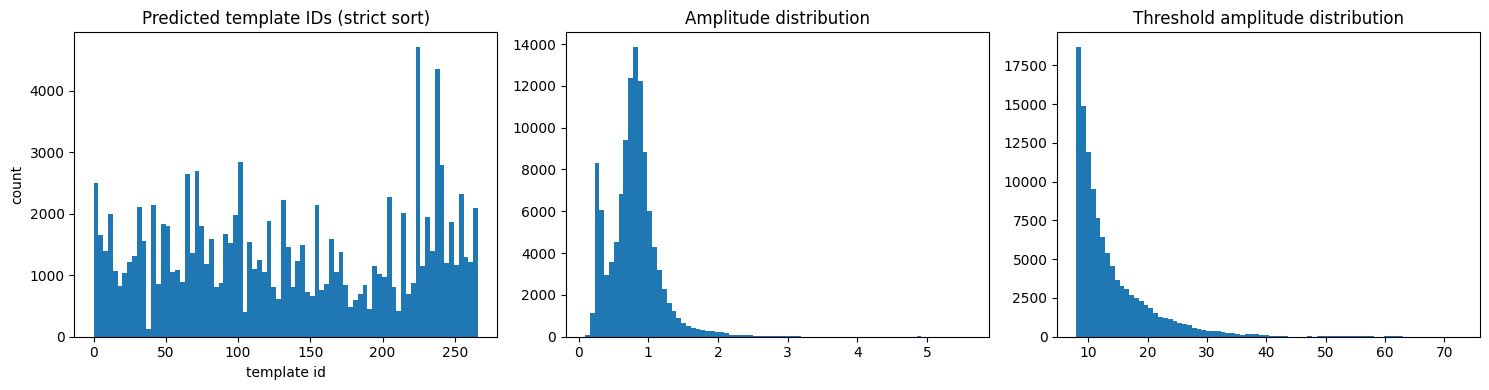

saved: F:\academic\week4_fixed_template_cluster_summary.csv


In [10]:
# Distributions and export
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

if st_cmp_fixed.size:
    ax[0].hist(clu_cmp_fixed, bins=80)
ax[0].set_title('Predicted template IDs (strict sort)')
ax[0].set_xlabel('template id')
ax[0].set_ylabel('count')

amp_ok = np.isfinite(amp_cmp_fixed)
if np.any(amp_ok):
    ax[1].hist(amp_cmp_fixed[amp_ok], bins=80)
ax[1].set_title('Amplitude distribution')

th_ok = np.isfinite(th_cmp_fixed)
if np.any(th_ok):
    ax[2].hist(th_cmp_fixed[th_ok], bins=80)
ax[2].set_title('Threshold amplitude distribution')

plt.tight_layout()
plt.show()

summary.to_csv(ROOT / 'week4_fixed_template_cluster_summary.csv', index=False)
print('saved:', ROOT / 'week4_fixed_template_cluster_summary.csv')


### Final accuracy metric: binned spike-count accuracy

The final accuracy metric below is no longer event-by-event agreement. Instead, it compares baseline and compressed sorting results after grouping spikes into fixed-width time bins.

The compressed path now uses `int16` bins as the storage / transmission format. Before Kilosort matching, each chunk is restored to `float32` with the per-channel scales saved in the paired `*_int16_meta.npy` file.

For each neuron and each bin, let `n_ref` be the baseline spike count and `n_test` be the compressed-data spike count. We define:

`matched_count = max(n_ref - abs(n_test - n_ref), 0)`

and the bin contribution is `matched_count / n_ref` when `n_ref > 0`. For example, if a unit fires 50 spikes in baseline and 55 spikes after compression, that bin contributes `45 / 50 = 0.90`.

This notebook reports the micro-average version of that score, i.e. total matched spikes across all units and bins divided by the total baseline spike count. The bin width is 1 second (`fs` samples).

> Note on `keep_ratio = 1.0`: even when all DCT coefficients are kept, the reported accuracy here does **not** have to be 100%.
> The reason is that the notebook measures **post-reconstruction sorting agreement**, not direct waveform identity.
> After reconstruction, quantization, re-reading, dequantization, re-matching, and re-binning, small numeric differences can still change threshold crossings or template assignments for a subset of events.


In [11]:
# RERUN NOTE: Must rerun after the CAR change. This cell regenerates reconstructed bins as needed and refreshes week4_ratio_*.npy plus the ratio-comparison outputs.
# Execute evaluation and output results
ratios = [0.10, 0.20, 0.30, 0.50, 0.70, 1.00]
rows = []
whitened_for_build = None
bin_size_samples = int(round(float(ops_base['fs'])))  # 1 second bins
if any(not is_valid_float32_bin(ROOT / f'whitened_recon_ratio_{r:.2f}.bin') for r in ratios):
    wp = ROOT / 'whitened_data.npy'
    if not wp.exists():
        raise FileNotFoundError('Missing ratio bin(s) and missing whitened_data.npy (CAR-corrected, bandpass-filtered, whitened) for reconstruction.')
    whitened_for_build = np.load(wp, mmap_mode='r')
for r in ratios:
    bp_float32 = ensure_recon_bin_for_ratio(r, whitened_data=whitened_for_build, force_rebuild=False)
    int16_bin, int16_meta = quantize_recon_bin_to_int16(bp_float32, r, overwrite=False)
    _, _, ch, _ = load_bin_window_as_float32(int16_bin, 0, 1)
    print(f'ratio={r:.2f} uses src_n_chan={ch} from int16 bin')
    bp = int16_bin

    cache_path = ratio_eval_cache_path(r)
    cache_required = {
        'pipeline_version', 'ratio', 'compressed_bin', 'source_float32_bin', 'int16_bin', 'int16_meta',
        'bin_size_samples', 'sample_rate',
        'n_baseline_events', 'n_detected_events',
        'detection_rate_on_baseline_events',
        'classification_accuracy_on_detected_events',
        'binned_count_accuracy_micro', 'binned_count_accuracy_macro',
        'matched_spikes_after_binning', 'baseline_spikes_for_binning', 'bin_size_seconds'
    }
    cached_metrics = load_npy_dict_if_valid(cache_path, required_keys=cache_required)
    if cached_metrics is not None:
        same_pipeline = cached_metrics.get('pipeline_version') == RATIO_EVAL_PIPELINE_VERSION
        same_bin = Path(cached_metrics['compressed_bin']) == Path(bp)
        same_source = Path(cached_metrics['source_float32_bin']) == Path(bp_float32)
        same_meta = Path(cached_metrics['int16_meta']) == Path(int16_meta)
        same_cfg = int(cached_metrics['bin_size_samples']) == int(bin_size_samples) and float(cached_metrics['sample_rate']) == float(ops_base['fs'])
        if same_pipeline and same_bin and same_source and same_meta and same_cfg:
            print(f'[ratio={r:.2f}] using cached evaluation: {cache_path.name}')
            rows.append(cached_metrics)
            continue

    m = eval_same_event_accuracy(bp, st_base, clu_base, U, ctc, ops_tm, n_use, nt, device, dshift=dshift_base if drift_enabled else None)
    st_cmp_ratio, clu_cmp_ratio = sort_full_timeline_with_fixed_templates(bp, U, ctc, ops_tm, n_use, nt, device, dshift=dshift_base if drift_enabled else None)
    m.update(eval_binned_count_accuracy(st_base, clu_base, st_cmp_ratio, clu_cmp_ratio, bin_size_samples, sample_rate=float(ops_base['fs']), n_units=U.shape[0]))
    m['pipeline_version'] = RATIO_EVAL_PIPELINE_VERSION
    m['ratio'] = f'{r:.2f}'
    m['compressed_bin'] = str(bp)
    m['source_float32_bin'] = str(bp_float32)
    m['sample_rate'] = float(ops_base['fs'])
    m['bin_size_samples'] = int(bin_size_samples)
    m['int16_bin'] = str(int16_bin)
    m['int16_meta'] = str(int16_meta)
    np.save(cache_path, m, allow_pickle=True)
    print(f'[ratio={r:.2f}] saved evaluation cache: {cache_path.name}')
    rows.append(m)
compare_df = pd.DataFrame(rows)[[
    'ratio',
    'n_baseline_events',
    'n_detected_events',
    'detection_rate_on_baseline_events',
    'classification_accuracy_on_detected_events',
    'binned_count_accuracy_micro',
    'binned_count_accuracy_macro',
    'matched_spikes_after_binning',
    'baseline_spikes_for_binning',
    'bin_size_seconds',
    'int16_bin',
    'source_float32_bin',
    'int16_meta',
]]
display(compare_df)
for _, r in compare_df.iterrows():
    ratio = r['ratio']
    det = r['detection_rate_on_baseline_events'] * 100
    cls = r['classification_accuracy_on_detected_events'] * 100 if np.isfinite(r['classification_accuracy_on_detected_events']) else np.nan
    binned_micro = r['binned_count_accuracy_micro'] * 100 if np.isfinite(r['binned_count_accuracy_micro']) else np.nan
    binned_macro = r['binned_count_accuracy_macro'] * 100 if np.isfinite(r['binned_count_accuracy_macro']) else np.nan
    print(f"ratio={ratio} | detection={det:.2f}% | classification={cls:.2f}% | binned_micro={binned_micro:.2f}% | binned_macro={binned_macro:.2f}%")
compare_df.to_csv(ROOT / 'week4_fixed_template_ratio_compare.csv', index=False)
print('saved:', ROOT / 'week4_fixed_template_ratio_compare.csv')


[ratio=0.10] using existing: whitened_recon_ratio_0.10.bin
ratio=0.10 uses src_n_chan=383 from int16 bin


TypeError: 'NoneType' object is not iterable

binned_count_accuracy_micro 是什么

  它是全局加权平均。

  做法是把所有神经元、所有 bin 的 matched spike 全部加起来，再除以 baseline 的总 spike 数：

  micro = total_matched_spikes / total_baseline_spikes

  含义：

  - 所有 spike 一视同仁
  - 发放多的神经元权重大
  - 更像“整体上保住了多少 spike count”

  如果一个高 firing-rate 神经元表现很好，它会显著拉高 micro。

  ———

  binned_count_accuracy_macro 是什么

  它是按神经元先分别算，再做平均。

  你的 notebook 逻辑是先对每个 neuron 算：

  matched_totals[unit] / ref_totals[unit]

  然后只对 ref_totals > 0 的神经元取平均：

  macro = mean(per-neuron accuracy)

  含义：

  - 每个神经元权重相同
  - 不管它 firing 多还是少
  - 更像“平均每个神经元保真度如何”

  所以低 firing-rate 神经元不会被高 firing-rate 神经元淹没。

  ———

  两者区别

  核心区别就是：是否按 spike 数加权。

  - micro
      - 以 spike 为中心
      - 高频神经元影响更大
      - 反映整体总量保留得怎么样

  - macro
      - 以 neuron 为中心
      - 每个神经元权重相同
      - 反映平均单元质量怎么样

  ———

  举个直观例子

  假设有两个神经元：

  1. 神经元 A
      - baseline: 1000 spikes
      - accuracy: 95%

  2. 神经元 B
      - baseline: 10 spikes
      - accuracy: 20%

  那么：

  - micro 会接近 95%
    因为 A 的 spike 太多，占主导

  - macro 会是：

    (95% + 20%) / 2 = 57.5%

  这说明：

  - 从“总 spike 数”看，结果很好
  - 但从“每个神经元平均表现”看，结果一般

  ———

  怎么解读你 notebook 里的这两个值

  - 如果 micro 高、macro 低：
    说明主要大单元/高 firing-rate 单元保得不错，但有些小单元丢得厉害

  - 如果 micro 和 macro 都高：
    说明整体和单元级别都比较稳定

  - 如果 micro 低、macro 还行：
    说明少数大单元出了问题，拖累了整体 spike 总量